In [1]:
from pathlib import Path

DATASET_DIR = Path("../dataset/brain_tumor_dataset")

print("Dataset exists:", DATASET_DIR.exists())
print("Dataset path:", DATASET_DIR.resolve())

Dataset exists: True
Dataset path: C:\Users\Asus\Desktop\image_classification\dataset\brain_tumor_dataset


In [2]:
classes = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

print("Classes:")
for cls in classes:
    print(cls)

Classes:
glioma
healthy
meningioma
pituitary


In [3]:
for cls in classes:
    images = list((DATASET_DIR / cls).glob("*.jpg"))
    print(f"{cls}: {len(images)} images")

glioma: 1621 images
healthy: 2000 images
meningioma: 1645 images
pituitary: 1757 images


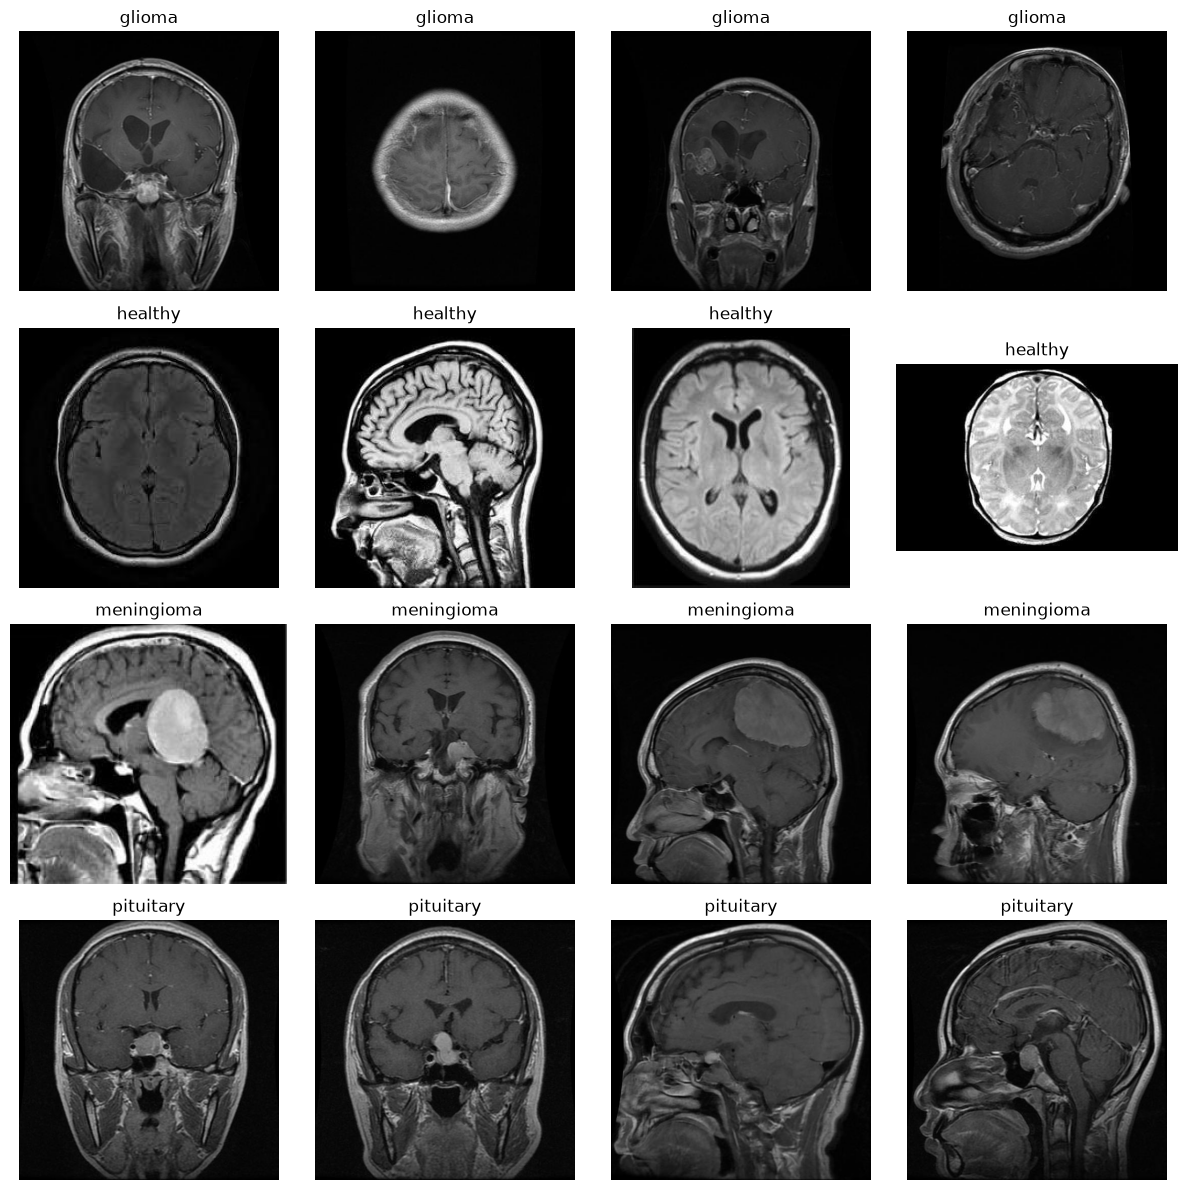

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for row, cls in enumerate(classes):
    image_files = list((DATASET_DIR / cls).glob("*.jpg"))
    selected = random.sample(image_files, 4)

    for col, image_path in enumerate(selected):
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import torch
from torchvision import transforms
from PIL import Image

In [6]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [7]:
image_path = list((DATASET_DIR / "glioma").glob("*.jpg"))[0]

image = Image.open(image_path)

print("Original size:", image.size)
print("Original mode:", image.mode)

Original size: (512, 512)
Original mode: RGB


In [8]:
tensor_image = preprocess(image)

print("Tensor shape:", tensor_image.shape)
print("Minimum value:", tensor_image.min().item())
print("Maximum value:", tensor_image.max().item())

Tensor shape: torch.Size([3, 224, 224])
Minimum value: 0.0
Maximum value: 0.8549019694328308


In [9]:
print(tensor_image)

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
         [0.0078, 0.0078, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0078, 0.0078, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
         [0.0078, 0.0078, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0078, 0.0078, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0039, 0.0039, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
         [0.0078, 0.0078, 0.0078,  ..., 0.0000, 0.0000, 0.

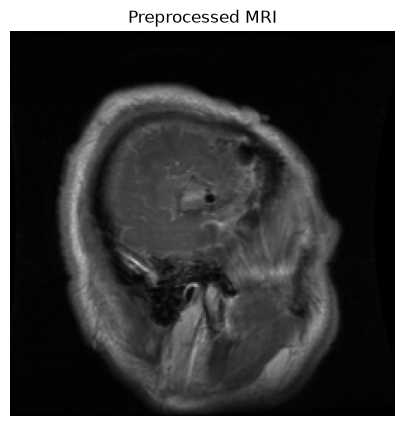

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.imshow(tensor_image.permute(1, 2, 0))

plt.title("Preprocessed MRI")
plt.axis("off")

plt.show()

In [11]:
for cls in classes:
    image_path = list((DATASET_DIR / cls).glob("*.jpg"))[0]
    image = Image.open(image_path)
    tensor_image = preprocess(image)

    print(
        cls,
        "| Original:", image.size,
        "| Tensor:", tuple(tensor_image.shape),
        "| Range:", (tensor_image.min().item(), tensor_image.max().item())
    )

glioma | Original: (512, 512) | Tensor: (3, 224, 224) | Range: (0.0, 0.8549019694328308)
healthy | Original: (225, 225) | Tensor: (3, 224, 224) | Range: (0.0, 1.0)
meningioma | Original: (512, 512) | Tensor: (3, 224, 224) | Range: (0.0, 0.9098039269447327)
pituitary | Original: (512, 512) | Tensor: (3, 224, 224) | Range: (0.0, 0.9098039269447327)


In [12]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

In [13]:
records = []

for label, cls in enumerate(classes):
    image_files = list((DATASET_DIR / cls).glob("*.jpg"))

    for image_path in image_files:
        records.append({
            "path": str(image_path),
            "class": cls,
            "label": label
        })

df = pd.DataFrame(records)

print(df.head())
print("\nTotal images:", len(df))

                                             path   class  label
0  ..\dataset\brain_tumor_dataset\glioma\0000.jpg  glioma      0
1  ..\dataset\brain_tumor_dataset\glioma\0001.jpg  glioma      0
2  ..\dataset\brain_tumor_dataset\glioma\0002.jpg  glioma      0
3  ..\dataset\brain_tumor_dataset\glioma\0003.jpg  glioma      0
4  ..\dataset\brain_tumor_dataset\glioma\0004.jpg  glioma      0

Total images: 7023


In [14]:
print(df["class"].value_counts())

class
healthy       2000
pituitary     1757
meningioma    1645
glioma        1621
Name: count, dtype: int64


In [15]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

In [17]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training: 4916
Validation: 1053
Testing: 1054
Total: 7023


In [18]:
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
healthy       1400
pituitary     1230
meningioma    1151
glioma        1135
Name: count, dtype: int64

VALIDATION
class
healthy       300
pituitary     263
meningioma    247
glioma        243
Name: count, dtype: int64

TESTING
class
healthy       300
pituitary     264
meningioma    247
glioma        243
Name: count, dtype: int64


In [19]:
## Duplicate Detection
import hashlib

def file_hash(path):
    hasher = hashlib.md5()

    with open(path, "rb") as f:
        while chunk := f.read(8192):
            hasher.update(chunk)

    return hasher.hexdigest()

In [20]:
hashes = {}

for path in df["path"]:
    h = file_hash(path)
    hashes.setdefault(h, []).append(path)

In [21]:
duplicates = {
    h: paths
    for h, paths in hashes.items()
    if len(paths) > 1
}

print("Number of duplicate groups:", len(duplicates))

Number of duplicate groups: 300


In [22]:
duplicate_group_sizes = [len(paths) for paths in duplicates.values()]

print("Duplicate groups:", len(duplicate_group_sizes))
print("Duplicate files involved:", sum(duplicate_group_sizes))
print("Extra copies:", sum(size - 1 for size in duplicate_group_sizes))
print("Largest duplicate group:", max(duplicate_group_sizes))

Duplicate groups: 300
Duplicate files involved: 726
Extra copies: 426
Largest duplicate group: 11


In [23]:
for i, paths in enumerate(duplicates.values(), start=1):
    classes_in_group = {
        Path(path).parent.name
        for path in paths
    }

    if len(classes_in_group) > 1:
        print(f"Group {i}:")
        print("Classes:", classes_in_group)
        for path in paths:
            print(" ", path)
        print()

In [24]:
path_to_split = {}

for path in train_df["path"]:
    path_to_split[path] = "train"

for path in val_df["path"]:
    path_to_split[path] = "validation"

for path in test_df["path"]:
    path_to_split[path] = "test"


leakage_groups = []

for i, paths in enumerate(duplicates.values(), start=1):
    splits = {
        path_to_split[path]
        for path in paths
    }

    if len(splits) > 1:
        leakage_groups.append((i, paths, splits))

print("Duplicate groups crossing splits:", len(leakage_groups))

Duplicate groups crossing splits: 154


In [25]:
cross_class_duplicates = []

for i, paths in enumerate(duplicates.values(), start=1):
    classes_in_group = {
        Path(path).parent.name
        for path in paths
    }

    if len(classes_in_group) > 1:
        cross_class_duplicates.append((i, paths, classes_in_group))

print("Duplicate groups with conflicting classes:",
      len(cross_class_duplicates))

Duplicate groups with conflicting classes: 0


In [26]:
for group_id, paths, classes_in_group in cross_class_duplicates[:10]:
    print(f"\nGroup {group_id}")
    print("Classes:", classes_in_group)

    for path in paths:
        print(" ", path)

In [29]:
duplicate_paths = set()

for paths in duplicates.values():
    # Keep the first image, exclude the remaining copies
    duplicate_paths.update(paths[1:])

print("Images excluded as duplicate copies:", len(duplicate_paths))

Images excluded as duplicate copies: 426


In [30]:
clean_df = df[~df["path"].isin(duplicate_paths)].copy()

print("Original images:", len(df))
print("Clean images:", len(clean_df))

Original images: 7023
Clean images: 6597


In [31]:
print(clean_df["class"].value_counts())

class
pituitary     1740
healthy       1706
glioma        1620
meningioma    1531
Name: count, dtype: int64


In [32]:
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [33]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training: 4617
Validation: 990
Testing: 990
Total: 6597


In [34]:
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
pituitary     1218
healthy       1194
glioma        1134
meningioma    1071
Name: count, dtype: int64

VALIDATION
class
pituitary     261
healthy       256
glioma        243
meningioma    230
Name: count, dtype: int64

TESTING
class
pituitary     261
healthy       256
glioma        243
meningioma    230
Name: count, dtype: int64


In [35]:
path_to_split = {}

for path in train_df["path"]:
    path_to_split[path] = "train"

for path in val_df["path"]:
    path_to_split[path] = "validation"

for path in test_df["path"]:
    path_to_split[path] = "test"


leakage_groups = []

for i, paths in enumerate(duplicates.values(), start=1):
    remaining_paths = [
        path for path in paths
        if path in path_to_split
    ]

    splits = {
        path_to_split[path]
        for path in remaining_paths
    }

    if len(splits) > 1:
        leakage_groups.append((i, remaining_paths, splits))

print("Duplicate groups crossing new splits:", len(leakage_groups))

Duplicate groups crossing new splits: 0


In [36]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image


class BrainTumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["path"]).convert("RGB")
        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [37]:
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [38]:
train_dataset = BrainTumorDataset(
    train_df,
    transform=basic_transform
)

val_dataset = BrainTumorDataset(
    val_df,
    transform=basic_transform
)

test_dataset = BrainTumorDataset(
    test_df,
    transform=basic_transform
)

In [39]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", classes[label])

Image shape: torch.Size([3, 224, 224])
Label: 2
Class: meningioma


In [40]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [41]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


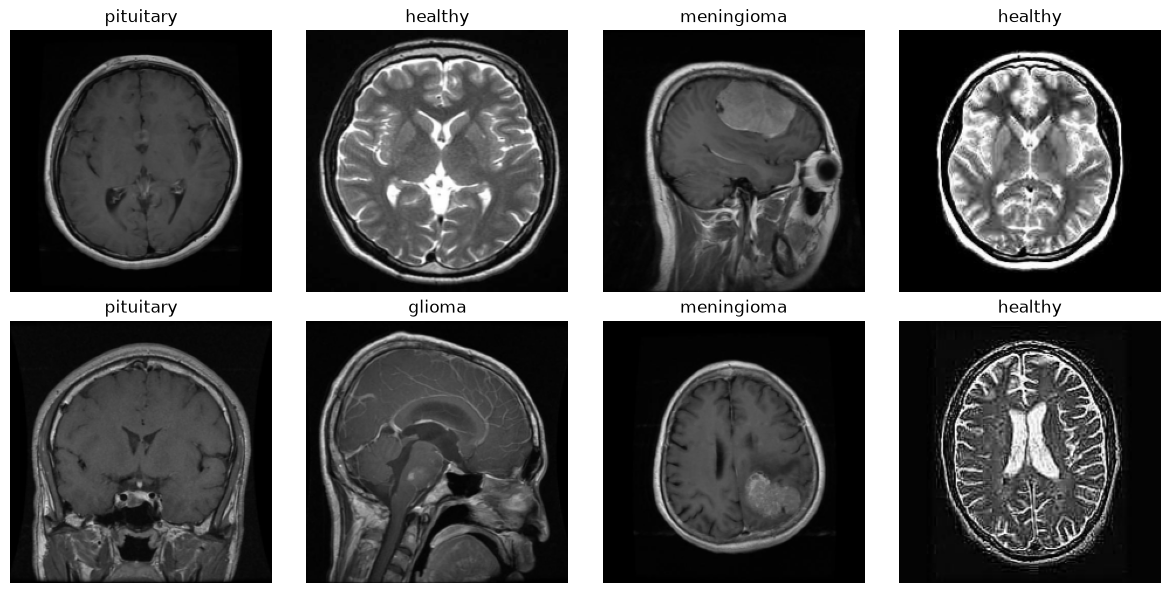

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(classes[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [44]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.fc1 = nn.Linear(
            32 * 56 * 56,
            128
        )

        self.fc2 = nn.Linear(
            128,
            4
        )

    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)

print(model)
print("Device:", device)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
Device: cpu


In [46]:
images, labels = next(iter(train_loader))

images = images.to(device)

output = model(images)

print("Input shape:", images.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 4])


In [47]:
criterion = nn.CrossEntropyLoss()